In [1]:
from pathlib import Path
from helpers import get_poi_upper_limit,get_signal_yieldsFrom,to_cut_name,get_model_pars
from spey import ExpectationType
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']


Spey - WARNING: A newer version (0.2.6) of Spey is available. Current version is 0.2.5.


## Get Recasting Results

In [2]:
results_dir = Path('./HeHe_results')
slha_dir = Path('./slhaFiles')
# usePickleFile = 'HeHe_results.pcl'
usePickleFile = False

In [3]:
if usePickleFile and Path(usePickleFile).exists():
    resultsDF = pd.read_pickle(usePickleFile)
else:
    resultsDict = {}
    for signal_file in results_dir.rglob('*signal.dat'):
        srDict = get_signal_yieldsFrom(Path(signal_file))
        slhaFile = Path(signal_file).parent.parent.name+ '.dat'
        slhaFile = Path(slha_dir, slhaFile)
        modelPars = get_model_pars(slhaFile)
        if modelPars in resultsDict:
            for key,val in srDict.items():
                resultsDict[modelPars][key] += val
        else:
            resultsDict[modelPars] = srDict
    resultsDF = pd.DataFrame.from_dict(resultsDict, orient='index')
    resultsDF.reset_index(inplace=True)
    resultsDF.rename(columns={'index':'modelPars', 'level_0' : 'M1', 'level_1' : 'M0'}, inplace=True)
    resultsDF.sort_values(by=['M1', 'M0'], inplace=True)
    resultsDF['muUL_observed'] = np.nan

SRcols = [col for col in resultsDF.columns if 'SR' in col]

### Compute combined upper limit

In [ ]:
def compute_poi_ul(row, expected=ExpectationType.observed,replace=False):
    signal_yields = row[SRcols].fillna(0.0).to_dict()
    muUL = row['muUL_observed']
    if np.isnan(muUL) or replace:
        return get_poi_upper_limit(signal_yields=signal_yields, expected=expected)
    else:
        return muUL

resultsDF['muUL_observed'] = resultsDF.apply(compute_poi_ul, axis=1)
resultsDF.to_pickle('HeHe_results.pcl')

### Plot results

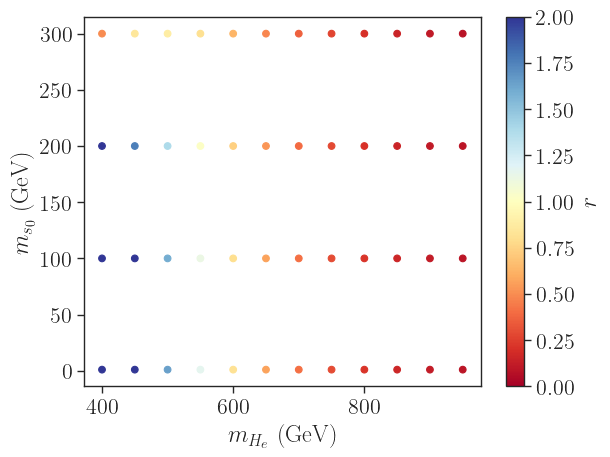

In [ ]:
plt.scatter(resultsDF['M1'], resultsDF['M0'], 
          c=1./resultsDF['muUL_observed'], 
          marker='o', cmap=cm,vmin=0.,vmax=2.0)
plt.xlabel(r'$m_{H_e}$ (GeV)')
plt.ylabel(r'$m_{s_0}$ (GeV)')
plt.colorbar(label=r'$r$')
plt.show()